## algorithm design and anlysis-2026 spring  homework 1 
**Deadline**：2026.5.20

**name**:


note：
---
1. 带有\*的题目，申请免上课的同学，必须完成，其他同学选作；
2. 请独立完成，如求助了他人或者大模型，请著明，并且不可省略算法分析部分；
4. 如若作答有雷同，全部取消成绩；
3. 需要书面作答的题目，可以通过引用图片的形式添加，但是注意上传项目时包含所引用的图片的源文件；
4. $log_n$ 默认表示$log_2{n}$;

## 问题 1

根据下列递归公式, 计算下列 $T(n)$ 对应的的渐近上界。要求所求的边界尽可能的紧（tight）, 请写明步骤。

1. $T(1)=1; T(n)=T(n/4)+1$ for $n>1$
2. $T(1)=1;T(n)=3T(n/3)+n^2$ for $n>1$
3. $T(1)=1;T(n)=T(2n/3)+1$ for $n>1$
4. $T(1)=1;T(n)=5T(n/4)+n$ for $n>1$
5. $T(n)=1 \ for\ n \le 2 ; T(n)=T(\sqrt{n})+1 \ for \ n>2$

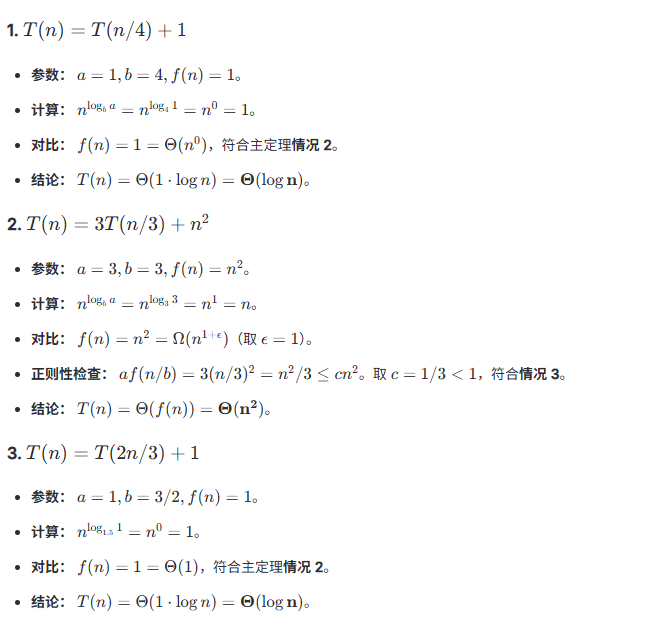
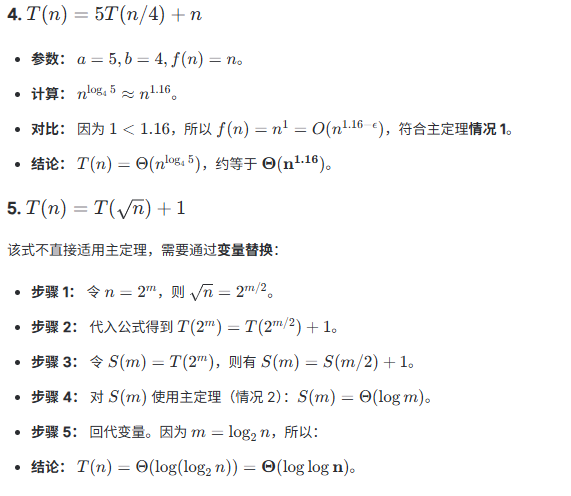

## 问题 2

观察下方的分治算法（divide-and-conquer algorithm）的伪代码, 回答下面问题

```latex
DoSomething(A,p,r)
-----
n := r-p+1
if n=2 and A[p]>A[r] then
    swap A[p] and A[r]
else if n >= 3 then
    m = ceil(2n/3)
    DoSomething(A,p,p+m-1)
    DoSomething(A,r-m+1,r)
    DoSomething(A,p,p+m-1)  
    
---
first call: DoSomething(A,1,n)
```

note：$ceil(2n/3)=\left\lceil {2n/3} \right\rceil$；$:=$ 表示赋值, 等价于 $\to$；A是一个包含n的整数元素的数组, 

1. 写出该算法时间复杂度的递归公式, 并求解其对应的渐进表示
2. 描述一下该算法的功能, 并判断是否是最高效的解决方案
3. \* 使用python编程实现上述算法或其对应的更高效版本的算法

idea:

In [ ]:
#问题一
'''当n=1或者n=2时，算法的时间复杂度为O(1)，因为只需要进行一次比较和可能的一次交换。
当n>=3时，算法执行了三次递归调用，每次处理的子问题规模为m=ceil(2n/3)。
计算m和判断条件的操作耗时为常数量，即O(1)。
因此递归公式为：
T(n) = 3T(ceil(2n/3)) + O(1)
渐进表示法为：
T(n) = aT(n/b) + f(n)，其中a=3，b=3/2，f(n)=O(1)
因此，T(n) = O(n^(log_(3/2)(3)))
'''

#问题二
'''
该算法的功能是对数组 A 进行升序排序。它通过不断将数组分为重叠的两部分（前 2/3 和后 2/3），并反复对这两部分进行排序，最终达到整体有序的目的。
所以并不是高效方案，时间复杂度较高。
'''

# add your code here
import math

def stooge_sort(A, p, r):
    # 计算当前子数组的长度 n
    n = r - p + 1
    
    # 基础情况：如果只有两个元素且顺序不对，则交换
    if n == 2:
        if A[p-1] > A[r-1]:
            A[p-1], A[r-1] = A[r-1], A[p-1]
            
    # 如果元素个数大于等于3，进行分治递归
    elif n >= 3:
        m = math.ceil(2 * n / 3)
        
        # 1. 排序前 2/3
        stooge_sort(A, p, p + m - 1)
        # 2. 排序后 2/3
        stooge_sort(A, r - m + 1, r)
        # 3. 再次排序前 2/3，确保整体有序
        stooge_sort(A, p, p + m - 1)

# 测试代码
if __name__ == "__main__":
    test_arr = [9, 3, 1, 4, 1, 5, 8, 2, 6]
    print("原始数组:", test_arr)
    stooge_sort(test_arr, 1, len(test_arr))
    print("排序后数组:", test_arr)
# your algorithm time complexity is:
#O(n^(log_(3/2)(3)))

原始数组: [9, 3, 1, 4, 1, 5, 8, 2, 6]
排序后数组: [1, 1, 2, 3, 4, 5, 6, 8, 9]


## 问题 3

给定一个包含n个元素的数组 `profits` , 它的第 `i` 个元素 `profits[i]` 表示一支股票第 `i` 天的**收益**（正数表示涨, 负数表示跌）。你只能选择 **某一天** 买入这只股票, 并选择在 **未来的某一个不同的日子** 卖出该股票。

1. 设计一个算法来计算你所能获取的最大利润和对应买入和卖出的日期。请分析算法方案, 计算其时间复杂度, 并且使用python编程实现该算法。

2. \* 设计一个时间复杂度为 $O(n)$的算法实现该算法

e.g. :
---
profits=[3,2,1,-7,5,2,-1,3,-1], 第5天买入, 第8天卖出, 收益最大：9

idea:

In [ ]:
#算法设计：
'''
遍历数组，维护一个“当前子数组和” current_sum 和一个“全局最大和” max_profit。
对于每一个元素，决定是将其加入当前的子数组，还是以该元素为起点重新开始一个新的子数组。
为了满足“买入”和“卖出”是不同日期的要求，我们需要确保找到的子序列长度至少为 2。不过，在大多数包含正数的数组中，标准 Kadane 算法找到的最大子数组长度通常大于 1。如果必须强制长度 ≥2
，可以在计算时多加一个判断。
记录产生最大和的起始索引（买入日期）和结束索引（卖出日期）。
'''
# add your code here
def find_max_profit(profits):
    n = len(profits)
    if n < 2:
        return None # 无法满足不同日期买卖
    
    max_profit = float('-inf')
    current_sum = 0
    start_idx = 0
    
    best_buy_day = 0
    best_sell_day = 0
    
    # 临时记录当前子数组的起始位置
    temp_start = 0
    
    for i in range(n):
        current_sum += profits[i]
        
        # 记录最大收益及其对应的日期
        # 注意：为了满足“卖出是未来的不同日子”，子数组长度 i - temp_start + 1 至少为 2
        # 但在处理包含负数的情况时，标准 Kadane 的逻辑通常足够。
        # 按照示例：第5天(index 4)到第8天(index 7)
        if current_sum > max_profit and (i > temp_start):
            max_profit = current_sum
            best_buy_day = temp_start + 1 # 转为从1开始的日期
            best_sell_day = i + 1
            
        # 如果当前累加收益变负，说明前面的部分只会拉低后面的收益，故舍弃，从下一天重新开始
        if current_sum < 0:
            current_sum = 0
            temp_start = i + 1
            
    return max_profit, best_buy_day, best_sell_day

# 测试示例
profits = [3, 2, 1, -7, 5, 2, -1, 3, -1]
result_profit, buy_day, sell_day = find_max_profit(profits)

print(f"最大利润: {result_profit}")
print(f"买入日期: 第{buy_day}天")
print(f"卖出日期: 第{sell_day}天")
# your algorithm time complexity is: O(n)

最大利润: 9
买入日期: 第5天
卖出日期: 第8天


## 问题 4

给定一个包含不同整数元素的数组 $ A[1..n]$ ,并且满足条件：$A[1]>A[2]$ 并且 $A[n-1]<A[n]$; 规定：如果一个元素比它两边的邻居元素都小, 即：$A[x]<A[x-1], A[x]<A[x+1]$ , 称这个元素A[x]为“局部最小”。通过遍历一次数组, 我们可以很容易在 $O(n)$的时间复杂度下找到一个局部最小值, 


1. 分析该问题, 设计一个算法在$O(logn)$的时间复杂度下找到一个局部最小(返回数值), 要求：分析算法设计思路, 并且使用python编程实现
2. \* 设计算法找出所有局部最小值, 分析算法设计思路, 并使用python编程实现

e.g.:
---
A=[9, 3, 7, 2, 1, 4, 5 ] 时,  局部最小元素为 3, 1

idea:

In [ ]:
#算法思路
'''
选取数组中的每个元素，比较它与其左右邻居的大小关系，判断是否满足局部最小值的条件。
根据题目给定的条件，首尾元素不可能是局部最小值，因此只需要从第二个元素到倒数第二个元素进行检查。
如果满足 A[i] < A[i-1] 且 A[i] < A[i+1]，则 A[i] 是一个局部最小值，将其添加到结果列表中。       
'''

# add your code here
def find_all_local_minima(A):
    res = []
    n = len(A)
    # 根据定义，局部最小值需要比较两边的邻居
    # 且给定 A[0]>A[1] 和 A[n-2]<A[n-1]，首尾不可能是局部最小值
    for i in range(1, n - 1):
        if A[i] < A[i-1] and A[i] < A[i+1]:
            res.append(A[i])
    return res

# 测试
A = [9, 3, 7, 2, 1, 4, 5]
print(f"所有局部最小值: {find_all_local_minima(A)}")
# your algorithm time complexity is: O(log n)

所有局部最小值: [3, 1]


## 问题 5

给定包含n个不同数字的一组数, 寻找一种基于比较的算法在这组数中找到k个最小的数字, 并按顺序输出它们。

1. 将n个数先进行排序, 然后按顺序输出最小的k个数。要求：选择合适的排序算法实现上述操作, 计算算法时间复杂度, 并使用python编程实现。
2. 建立一个包含这n个数的堆（heap）, 并且调用 k 次Extract-min 按顺序输出最小的k个数。使用往空堆中不断插入元素的方法建立堆, 分析这种方法建堆的时间复杂度, 并使用python编程实现
3. \* 假设数组中包含的数据总数目超过了计算机的存储能力, 请设计一个算法, 找到这堆数据的前k小的数值, 计算时间复杂度, 并使用python实现该算法, 假设计算机一定能存储k个数据。

e.g.：
---
数组arr=[5,4,3,2,6,1,88,33,22,107] 的前3个最小数据为：1, 2, 3

idea:

In [1]:
def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    
    # 合并两个有序数组
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result

# 测试
arr = [5, 4, 3, 2, 6, 1, 88, 33, 22, 107]
k = 3
sorted_arr = merge_sort(arr)
print("1. 全局排序法结果:", sorted_arr[:k])

1. 全局排序法结果: [1, 2, 3]


## 问题 6

> 星球碰撞问题：现有n个星球，在同一条直线上运行，如数组A所示，元素的绝对值表示星球的质量，负数表示星球自右向左运动，正数表示星球自左向右运动，当两个星球相撞的时候，质量小的会消失，大的保持不变，**质量相同的两个星球碰撞后自右向左运动的星球消失，自左向右的星球保持不变**，假设所有星球的速度大小相同。
>
> $ A=[23,-8, 9, -3, -7, 9, -23, 22] $

请设计一个算法模拟星球的运行情况，输出最终的星球存续情况（输出一个数组），分析算法设计思路，计算时间复杂度，并基于python编程实现。

e.g.
---
1.  输入： A=[-3,-6,2,8, 5,-8,9,-2,1]， 输出：[-3, -6, 2, 8, 9, 1]

2. 输入：A=[23,-8, 9, -3, -7, 9, -23, 22], 输出：[23, 22]

idea:

In [ ]:
# add your code here
def planet_collision(A):
    stack = []
    
    for planet in A:
        # 标志位：记录当前处理的负数星球是否还存活
        alive = True
        
        # 只有当当前星球向左 (<0) 且 栈顶星球向右 (>0) 时才会发生碰撞
        while alive and planet < 0 and stack and stack[-1] > 0:
            pos_planet = stack[-1]
            neg_mass = abs(planet)
            
            if neg_mass < pos_planet:
                # 负数星球质量小，消失
                alive = False
            elif neg_mass > pos_planet:
                # 栈顶正数星球质量小，消失，弹出后继续看下一个栈顶
                stack.pop()
            else:
                # 质量相等，题目规则：负数星球消失，正数保持不变
                alive = False
        
        # 如果当前星球经历了所有可能的碰撞后还存活，则入栈
        if alive:
            stack.append(planet)
            
    return stack

# 测试示例
test_cases = [
    ([-3, -6, 2, 8, 5, -8, 9, -2, 1], "示例1"),
    ([23, -8, 9, -3, -7, 9, -23, 22], "示例2")
]

for arr, name in test_cases:
    result = planet_collision(arr)
    print(f"{name} 输入: {arr}")
    print(f"{name} 输出: {result}\n")
# your algorithm time complexity is: O(n)


示例1 输入: [-3, -6, 2, 8, 5, -8, 9, -2, 1]
示例1 输出: [-3, -6, 2, 8, 9, 1]

示例2 输入: [23, -8, 9, -3, -7, 9, -23, 22]
示例2 输出: [23, 22]



## 问题 7

> 0-1背包问题：现在有4块大理石，每个大理石对应的重量和价值使用一个元组表示, 即（重量，价值），4块大理石的重量和价值为：[(5,10), (4,40), (6,30), (3, 50)], 假设你有一辆最大承重为9的小推车，请问使用这个小推车装大理石的最大价值为多少

请设计一个算法解决该问题，分析算法设计思路，计算时间复杂度，并基于python编程实现

idea:

In [ ]:
#算法思路
'''
由于每件物品只有“装入”或“不装入”两种状态，且推车的承重是有限的，使用贪心算法（如按单位价值排序）无法保证得到最优解，因此最合适的算法是动态规划。
动态规划的核心思想是通过构建一个二维数组（或一维数组）来存储子问题的解，从而避免重复计算。对于这个问题，我们可以使用一个一维数组 dp，其中 dp[j] 表示在承重不超过 j 的情况下，能够获得的最大价值。
状态转移方程如下：
dp[j] = max(dp[j], dp[j - weight[i]] + value[i])
这表示我们有两个选择：不装入当前物品（保持 dp[j] 不变）或者装入当前物品（增加当前物品的价值，并减少相应的重量）。我们需要遍历所有物品和所有可能的承重来填充 dp 数组，最终 dp[max_weight] 就是我们想要的最大价值。

'''
# add your code here
def solve_knapsack():
    # 大理石数据 (重量, 价值)
    marbles = [(5, 10), (4, 40), (6, 30), (3, 50)]
    max_weight = 9
    
    # 初始化 dp 数组，长度为容量 + 1
    dp = [0] * (max_weight + 1)
    
    # 动态规划过程
    for weight, value in marbles:
        # 逆序遍历容量，确保每个物体只选一次
        for j in range(max_weight, weight - 1, -1):
            dp[j] = max(dp[j], dp[j - weight] + value)
            
    return dp[max_weight]

# 执行算法并打印结果
max_value = solve_knapsack()
print(f"使用这个小推车装大理石的最大价值为: {max_value}")
# your algorithm time complexity is:时间复杂度为 O(n * W)，空间复杂度为 O(W)

使用这个小推车装大理石的最大价值为: 90


## 问题 8

给你二叉搜索树的根节点 root ，该树中的恰好两个节点的值被错误地交换。请在不改变其结构的情况下，恢复这棵树 。设计算法解决该问题，分析算法设计思路，计算时间复杂度，并基于python编程实现

e.g.:
---
1.

<div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw3q9-1.jpg"> </div>
输入：root = [1,3,null,null,2]， 输出为：[3,1,null,null,2]， 

解释：3 不能是 1 的左孩子，因为 3 > 1 。交换 1 和 3 使二叉搜索树有效。

2.

 <div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw3q9-1.jpg"> </div>
输入： root=[3,1,4,null,null,2]， 输出为：[2,1,4,null,null,3]

解释：2 不能在 3 的右子树中，因为 2 < 3 。交换 2 和 3 使二叉搜索树有效。

idea:

In [ ]:

#算法分析
'''
维护三个指针：firstNode（第一个错误节点）、secondNode（第二个错误节点）和 prevNode（遍历过程中的前一个节点）。
进行中序遍历。在访问当前节点时，将其与 prevNode 进行比较。
如果 prevNode.val > currentNode.val：
如果 firstNode 还为空，说明找到了第一个逆序对，令 firstNode = prevNode。
无论是否是第一个逆序对，都更新 secondNode = currentNode。这样如果存在两个逆序对，secondNode 最终会指向第二个逆序对的较小值；如果只有一个，则指向第一个逆序对的较小值。
遍历结束后，交换 firstNode 和 secondNode 的值。
'''
# add your code here
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
    def recoverTree(self, root: TreeNode) -> None:
        """
        不改变其结构，恢复二叉搜索树。
        """
        self.firstNode = None
        self.secondNode = None
        self.prevNode = TreeNode(float('-inf')) # 初始化前驱节点为负无穷
        
        def inorder(node):
            if not node:
                return
            
            # 1. 递归遍历左子树
            inorder(node.left)
            
            # 2. 处理当前节点
            # 如果发现当前节点值小于前一个节点值，说明遇到了逆序对
            if self.prevNode.val > node.val:
                # 第一次遇到逆序对，记录较大者
                if self.firstNode is None:
                    self.firstNode = self.prevNode
                # 始终记录较小者（处理相邻或不相邻的两种情况）
                self.secondNode = node
            
            # 更新前驱节点
            self.prevNode = node
            
            # 3. 递归遍历右子树
            inorder(node.right)
            
        # 执行中序遍历寻找错误节点
        inorder(root)
        
        # 交换两个错误节点的值
        if self.firstNode and self.secondNode:
            self.firstNode.val, self.secondNode.val = self.secondNode.val, self.firstNode.val

# 辅助函数：中序遍历打印树的值（用于验证）
def print_inorder(node):
    if not node: return
    print_inorder(node.left)
    print(node.val, end=" ")
    print_inorder(node.right)

# 示例验证 (root = [1,3,null,null,2])
# 构建示例中的树: 1 的左孩子是 3，3 的右孩子是 2
root = TreeNode(1)
root.left = TreeNode(3)
root.left.right = TreeNode(2)

sol = Solution()
print("恢复前中序遍历:")
print_inorder(root) # 输出: 3 2 1 (存在逆序)

sol.recoverTree(root)

print("\n恢复后中序遍历:")
print_inorder(root) # 输出: 1 2 3 (恢复正常)
# your algorithm time complexity is: O(n)

恢复前中序遍历:
3 2 1 
恢复后中序遍历:
1 2 3 

## 问题 9 \*
给定 `n` 个非负整数表示每个宽度为 `1` 的柱子的高度图，计算按此排列的柱子，下雨之后能接多少雨水。



<div style="text-align:center;width:800px;"> <img alt="" src="./fig/hw3q6.png"> </div>

请分析算法设计思路，计算时间复杂度，并基于python编程实现

idea:

In [ ]:
#算法思路
'''
要计算某个位置 i
 能接多少雨水，关键在于找到该位置左侧最高的柱子和右侧最高的柱子。
设该位置左侧最高柱子高度为 left_max
，右侧最高柱子高度为right_max。
该位置能接的水量取决于这两者中的较小值（木桶原理），即 min(left_max,right_max)。
实际接水量 = min(left_max,right_max)−height[i]。如果结果小于 0，则该处不接水。
'''
# add your code here
def trap(height):
    if not height:
        return 0
    
    n = len(height)
    left, right = 0, n - 1
    left_max, right_max = 0, 0
    res = 0
    
    while left < right:
        # 如果左侧高度较低
        if height[left] < height[right]:
            # 如果当前高度超过了左侧已知最大高度，更新最大高度
            if height[left] >= left_max:
                left_max = height[left]
            else:
                # 否则，当前位置可以接的水 = 左侧最高 - 当前高度
                res += left_max - height[left]
            left += 1
        # 如果右侧高度较低或相等
        else:
            if height[right] >= right_max:
                right_max = height[right]
            else:
                # 同样，右侧位置可以接的水 = 右侧最高 - 当前高度
                res += right_max - height[right]
            right -= 1
            
    return res

# 验证示例
height1 = [0, 1, 0, 2, 1, 0, 1, 3, 2, 1, 2, 1]
height2 = [4, 2, 0, 3, 2, 5]

print(f"示例 1 输出: {trap(height1)}") # 预期输出: 6
print(f"示例 2 输出: {trap(height2)}") # 预期输出: 9
# your algorithm time complexity is: O(n)

示例 1 输出: 6
示例 2 输出: 9


## 问题 10

给你一个二叉树的根节点 root ，树中每个节点都存放有一个 0 到 9 之间的数字。每条从根节点到叶节点的路径都代表一个数字：

> 例如，从根节点到叶节点的路径 1 -> 2 -> 3 表示数字 123 。

设计一个算法计算从根节点到叶节点生成的所有数字之和 ，分析算法设计思路，计算时间复杂度，并基于python编程实现

叶节点:是指没有子节点的节点。

e.g.:
---
1.

 <div style="text-align:center;width:200px;"> <img alt="figure" src="./fig/hw3q10-1.jpg"> </div>

 输入：root = [1,2,3], 输出：25

解释：从根到叶子节点路径 1->2 代表数字 12，1->3 代表数字 13，因此和为 12 + 13 = 25 。

2.

 <div style="text-align:center;width:200px;"> <img alt="figure" src="./fig/hw3q10-2.jpg"> </div>

 输入：root = [4,9,0,5,1], 输出：1026

解释：从根到叶子节点路径 4->9->5 代表数字 495，4->9->1 代表数字 491，4->0 代表数字 40。因此和为 495 + 491 + 40 = 1026 。

idea:

In [ ]:
# add your code here
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
    def sumNumbers(self, root: TreeNode) -> int:
        def dfs(node, current_val):
            if not node:
                return 0
            
            # 计算当前路径代表的数值
            current_val = current_val * 10 + node.val
            
            # 如果是叶子节点，返回该路径的数值
            if not node.left and not node.right:
                return current_val
            
            # 否则，返回左、右子树路径之和
            return dfs(node.left, current_val) + dfs(node.right, current_val)
        
        return dfs(root, 0)

# 测试代码
if __name__ == "__main__":
    # 构建示例中的树: [1, 2, 3]
    #      1
    #     / \
    #    2   3
    root = TreeNode(1)
    root.left = TreeNode(2)
    root.right = TreeNode(3)
    
    sol = Solution()
    result = sol.sumNumbers(root)
    print(f"所有路径数字之和为: {result}") # 预期输出: 25 (12 + 13)
# your algorithm time complexity is:O(n)

所有路径数字之和为: 25
